# 🏟️ Análisis Exploratorio — LaLiga 2023/24
**Proyecto S1 | Sports Analytics Portfolio**  
Herramientas: Python · Pandas · Matplotlib · Seaborn  
Dataset: La Liga Stats 2023-2024 (Kaggle)

---
## Objetivos
1. Limpiar y explorar el dataset de jugadores de LaLiga 23/24
2. Identificar los mejores equipos por métricas ofensivas y defensivas
3. Encontrar los jugadores más destacados por posición
4. Descubrir patrones e insights no obvios en los datos

## 0. Setup e Importaciones

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Estilo visual profesional
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Blues_d')

LALIGA_RED = '#EE1726'
LALIGA_BLUE = '#00378B'
ACCENT = '#F5A623'

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


## 1. Carga y Exploración Inicial

In [43]:
# Carga del dataset
df = pd.read_csv(r'C:\Users\jrubi\Desktop\Sports-Analytics Portfolio\S1 EDA La LIga\data\laliga_2324.csv')

df = df[df['competition'] == 'Classics'].reset_index(drop=True)
print(f'📊 Shape: {df.shape[0]} jugadores × {df.shape[1]} columnas')
print(f'🏟️  Equipos: {df["team"].nunique()}')
print(f'👤 Jugadores únicos: {df["name"].nunique()}')
print(f'📍 Posiciones: {df["position"].unique()}')
print(f'📊 Shape tras deduplicar: {df.shape[0]} jugadores × {df.shape[1]} columnas')

📊 Shape: 723 jugadores × 150 columnas
🏟️  Equipos: 47
👤 Jugadores únicos: 718
📍 Posiciones: ['Goalkeeper' 'Forward' 'Midfielder' 'Defender' nan]
📊 Shape tras deduplicar: 723 jugadores × 150 columnas


## 2. Limpieza de Datos

In [66]:
# Columnas relevantes para análisis de campo
cols_keep = [
    'name', 'team', 'position', 'date_of_birth', 'country',
    'games_played', 'starts', 'time_played',
    'goals', 'goal_assists', 'total_shots', 'shots_on_target_inc_goals',
    'goals_from_inside_box', 'goals_from_outside_box',
    'successful_dribbles', 'unsuccessful_dribbles',
    'total_passes', 'total_successful_passes_excl_crosses_corners',
    'key_passes_attempt_assists', 'through_balls',
    'total_tackles', 'tackles_won', 'interceptions',
    'duels', 'duels_won',
    'yellow_cards', 'total_red_cards',
    'successful_crosses_open_play', 'aerial_duels_won',
    'touches', 'recoveries'
]

df = df[cols_keep].copy()

# Extraer año de nacimiento para calcular edad
df['birth_year'] = pd.to_datetime(df['date_of_birth'], errors='coerce').dt.year
df['age'] = 2024 - df['birth_year']

# Filtrar: solo jugadores de campo con al menos 1 partido jugado
df_campo = df[
    (df['position'] != 'Goalkeeper') &
    (df['games_played'] > 0) &
    (df['time_played'].notna()) &
    (df['team'].isin(equipos_laliga))
].copy()

# Rellenar nulos con 0 en métricas numéricas
cols_num = df_campo.select_dtypes(include='number').columns
df_campo[cols_num] = df_campo[cols_num].fillna(0)

# Métricas por 90 minutos (clave en analytics moderno)
df_campo['min_jugados'] = df_campo['time_played'].astype(float)
df_campo['90s'] = df_campo['min_jugados'] / 90

# Solo jugadores con más de 450 min (5 partidos completos) para métricas por 90
df_min = df_campo[df_campo['min_jugados'] >= 450].copy()

df_min['goles_p90']          = df_min['goals'] / df_min['90s']
df_min['asistencias_p90']    = df_min['goal_assists'] / df_min['90s']
df_min['contribuciones_p90'] = df_min['goles_p90'] + df_min['asistencias_p90']
df_min['tiros_p90']          = df_min['total_shots'] / df_min['90s']
df_min['tiros_puerta_p90']   = df_min['shots_on_target_inc_goals'] / df_min['90s']
df_min['precision_tiro']     = np.where(
    df_min['total_shots'] > 0,
    df_min['shots_on_target_inc_goals'] / df_min['total_shots'] * 100, 0
)
df_min['pases_exitosos_p90'] = df_min['total_successful_passes_excl_crosses_corners'] / df_min['90s']
df_min['regates_exitosos_p90'] = df_min['successful_dribbles'] / df_min['90s']
df_min['recuperaciones_p90'] = df_min['recoveries'] / df_min['90s']

print(f'✅ Dataset limpio: {df_min.shape[0]} jugadores con +450 minutos')
print(f'   Equipos representados: {df_min["team"].nunique()}')
df_min[['name','team','position','games_played','goals','goal_assists','goles_p90']].head(5)

✅ Dataset limpio: 377 jugadores con +450 minutos
   Equipos representados: 20


,name,team,position,games_played,goals,goal_assists,goles_p90
1,Abde Ezzalzouli,Real Betis,Forward,26.0,1.0,0.0,0.105386
3,Abde Rebbach,Deportivo Alavés,Midfielder,23.0,1.0,0.0,0.126050
4,Abdel Abqar,Deportivo Alavés,Defender,27.0,0.0,0.0,0.000000
5,Abdul Mumin,Rayo Vallecano,Defender,20.0,1.0,0.0,0.053097
6,Abdón Prats,RCD Mallorca,Forward,34.0,6.0,1.0,0.429253


## 3. Análisis por Equipos

In [68]:
equipos = df_campo.groupby('team').agg(
    jugadores          = ('name', 'count'),
    goles_totales      = ('goals', 'sum'),
    asistencias        = ('goal_assists', 'sum'),
    tiros_totales      = ('total_shots', 'sum'),
    tiros_puerta       = ('shots_on_target_inc_goals', 'sum'),
    regates            = ('successful_dribbles', 'sum'),
    recuperaciones     = ('recoveries', 'sum'),
    tackles_ganados    = ('tackles_won', 'sum'),
    intercepciones     = ('interceptions', 'sum'),
    tarjetas_amarillas = ('yellow_cards', 'sum'),
    max_minutos        = ('time_played', 'max')   # ← el jugador con más min = partidos del equipo
).reset_index()

# El jugador con más minutos jugados en el equipo define los partidos del equipo
equipos['partidos_jugados']  = (equipos['max_minutos'] / 90).round().astype(int)
equipos['goles_por_partido'] = equipos['goles_totales'] / equipos['partidos_jugados']
equipos['precision_disparo'] = equipos['tiros_puerta'] / equipos['tiros_totales'] * 100
equipos['contribuciones']    = equipos['goles_totales'] + equipos['asistencias']

print('Top 5 equipos más goleadores:')
print(equipos.nlargest(5, 'goles_totales')[['team','goles_totales','goles_por_partido','precision_disparo']].to_string(index=False))

Top 5 equipos más goleadores:
              team  goles_totales  goles_por_partido  precision_disparo
       Real Madrid           85.0           2.656250          55.580357
         Girona FC           84.0           2.333333          50.526316
      FC Barcelona           76.0           2.303030          53.613054
Atlético de Madrid           68.0           2.193548          54.691689
     Villarreal CF           62.0           2.137931          50.470219


In [70]:
df = pd.read_csv(r'C:\Users\jrubi\Desktop\Sports-Analytics Portfolio\S1 EDA La LIga\data\laliga_2324.csv')

# Quedarse con una fila por jugador
df = df[df['competition'] == 'Classics'].reset_index(drop=True)

# Solo equipos LaLiga 23/24
equipos_laliga = [
    'Real Madrid', 'FC Barcelona', 'Atlético de Madrid', 'Girona FC',
    'Athletic Club', 'Real Sociedad', 'Real Betis', 'Villarreal CF',
    'Valencia CF', 'Getafe CF', 'Deportivo Alavés', 'CA Osasuna',
    'RC Celta', 'Rayo Vallecano', 'Sevilla FC', 'Cádiz CF',
    'UD Almería', 'Granada CF', 'UD Las Palmas', 'RCD Mallorca'
]
df = df[df['team'].isin(equipos_laliga)].reset_index(drop=True)

print(f'✅ Shape: {df.shape[0]} jugadores · {df["team"].nunique()} equipos')

✅ Shape: 637 jugadores · 20 equipos


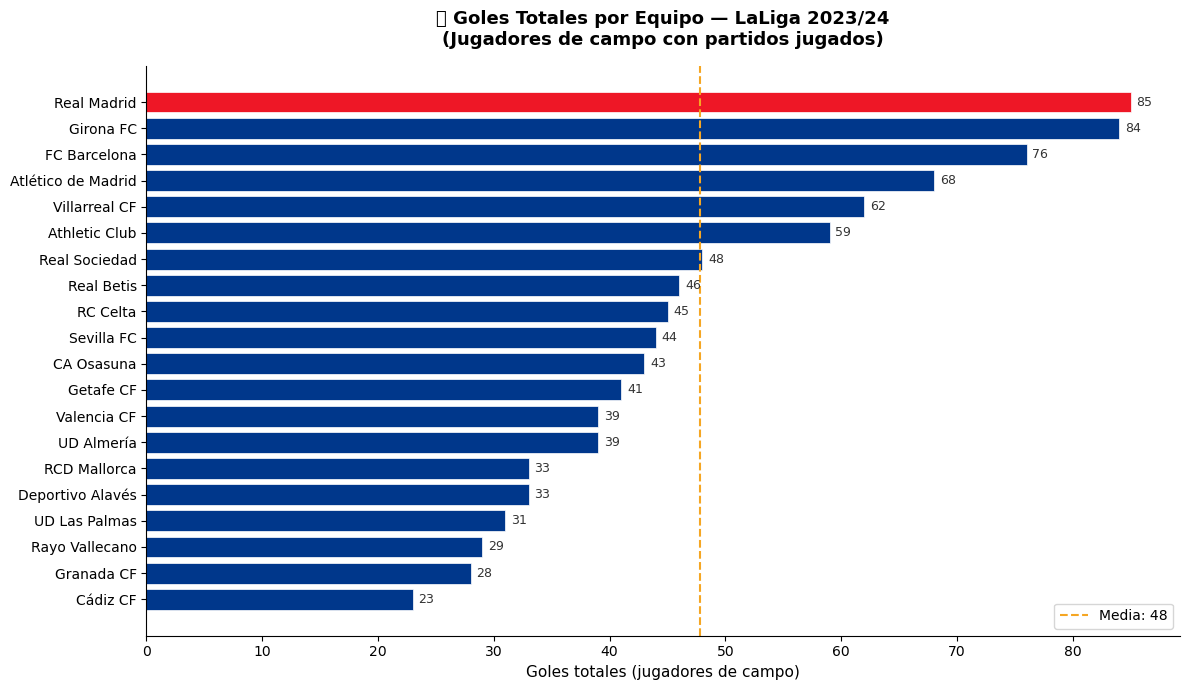

✅ Gráfico 1 guardado


In [72]:
# GRÁFICO 1: Goles totales por equipo
fig, ax = plt.subplots(figsize=(12, 7))

equipos_sorted = equipos.sort_values('goles_totales', ascending=True)
colors = [LALIGA_RED if g == equipos_sorted['goles_totales'].max() else LALIGA_BLUE 
          for g in equipos_sorted['goles_totales']]

bars = ax.barh(equipos_sorted['team'], equipos_sorted['goles_totales'], 
               color=colors, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, equipos_sorted['goles_totales']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{int(val)}', va='center', fontsize=9, color='#333333')

ax.set_xlabel('Goles totales (jugadores de campo)', fontsize=11)
ax.set_title('⚽ Goles Totales por Equipo — LaLiga 2023/24\n(Jugadores de campo con partidos jugados)', 
             fontsize=13, fontweight='bold', pad=15)
ax.axvline(equipos['goles_totales'].mean(), color=ACCENT, linestyle='--', linewidth=1.5, label=f'Media: {equipos["goles_totales"].mean():.0f}')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('output/01_goles_por_equipo.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfico 1 guardado')

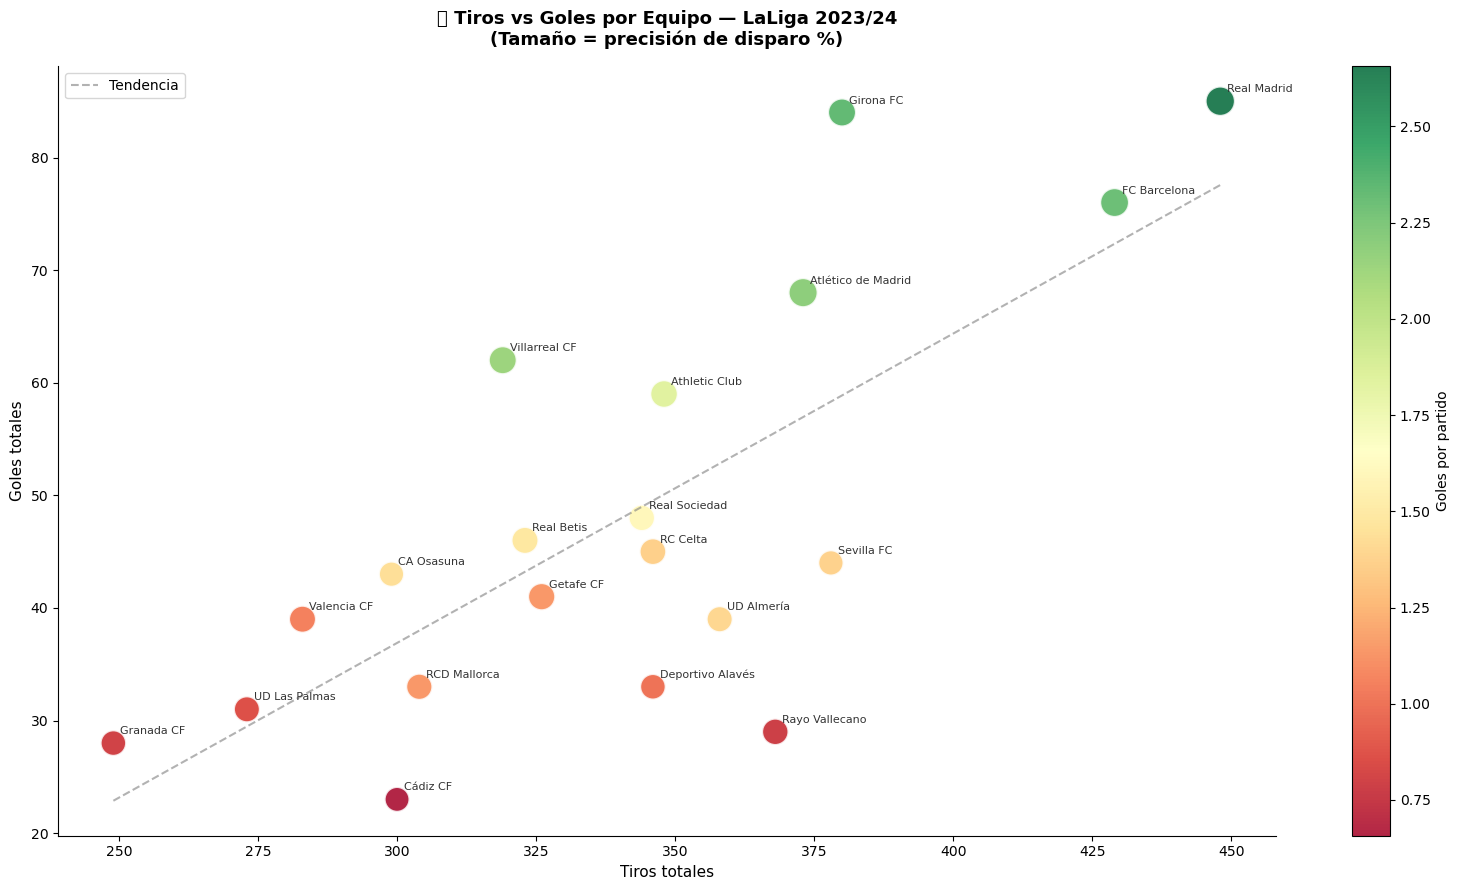

In [92]:
fig, ax = plt.subplots(figsize=(16, 9))  # más grande

scatter = ax.scatter(
    equipos['tiros_totales'], 
    equipos['goles_totales'],
    s=equipos['precision_disparo'] * 8,
    c=equipos['goles_por_partido'],
    cmap='RdYlGn', alpha=0.85, edgecolors='white', linewidth=1.5
)

for _, row in equipos.iterrows():
    ax.annotate(
        row['team'],
        (row['tiros_totales'], row['goles_totales']),
        fontsize=8, ha='left', va='bottom',
        xytext=(5, 5), textcoords='offset points',
        color='#333333'
    )

z = np.polyfit(equipos['tiros_totales'], equipos['goles_totales'], 1)
p = np.poly1d(z)
x_line = np.linspace(equipos['tiros_totales'].min(), equipos['tiros_totales'].max(), 100)
ax.plot(x_line, p(x_line), '--', color='gray', alpha=0.6, linewidth=1.5, label='Tendencia')

plt.colorbar(scatter, ax=ax, label='Goles por partido')
ax.set_xlabel('Tiros totales', fontsize=11)
ax.set_ylabel('Goles totales', fontsize=11)
ax.set_title('🎯 Tiros vs Goles por Equipo — LaLiga 2023/24\n(Tamaño = precisión de disparo %)', 
             fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('output/02_tiros_vs_goles_equipos.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Análisis de Jugadores

In [102]:
# Top goleadores
top_goleadores = df_min.nlargest(10, 'goals')[['name','team','position','games_played','goals','goal_assists','goles_p90','precision_tiro']]
print('🥇 TOP 10 GOLEADORES — LaLiga 2023/24')
print(top_goleadores.round(2).to_string(index=False))

🥇 TOP 10 GOLEADORES — LaLiga 2023/24
                                   name               team   position  games_played  goals  goal_assists  goles_p90  precision_tiro
                           Artem Dovbyk          Girona FC    Forward          36.0   24.0           8.0       0.83           59.74
                      Alexander Sørloth      Villarreal CF    Forward          34.0   23.0           6.0       0.83           61.02
                        Jude Bellingham        Real Madrid Midfielder          28.0   19.0           6.0       0.74           71.43
                     Robert Lewandowski       FC Barcelona    Forward          35.0   19.0           8.0       0.62           62.32
                           Ante Budimir         CA Osasuna    Forward          33.0   17.0           2.0       0.62           58.33
                      Antoine Griezmann Atlético de Madrid    Forward          33.0   16.0           6.0       0.54           60.71
                      Youssef En-Nesyri

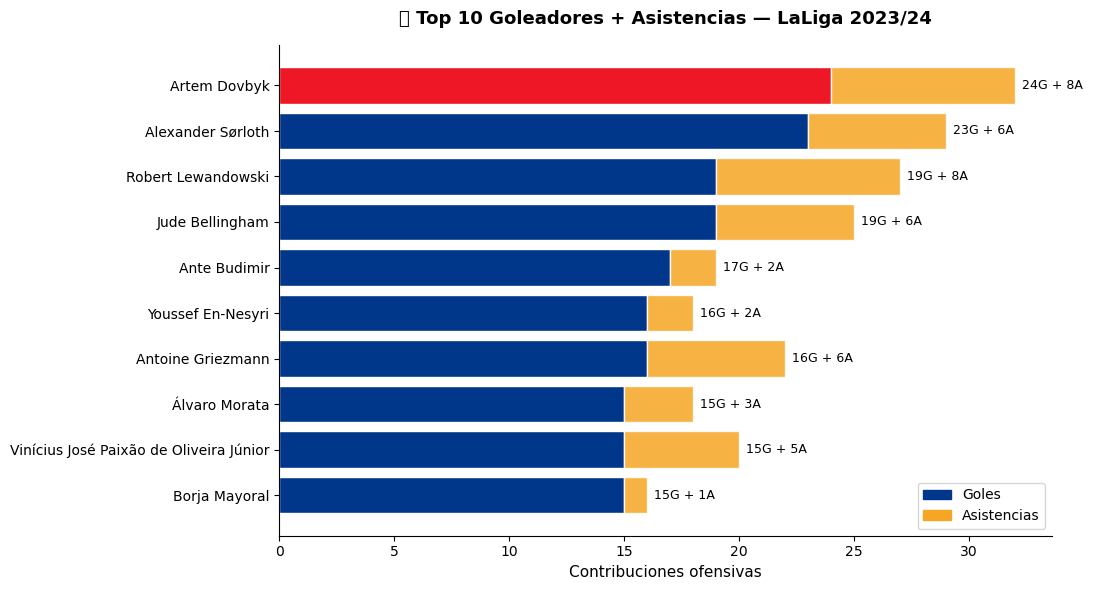

✅ Gráfico 3 guardado


In [104]:
# GRÁFICO 3: Top 10 goleadores
top10_g = df_min.nlargest(10, 'goals').sort_values('goals')

fig, ax = plt.subplots(figsize=(11, 6))

colors_g = [LALIGA_RED if i == len(top10_g)-1 else LALIGA_BLUE for i in range(len(top10_g))]
bars = ax.barh(top10_g['name'], top10_g['goals'], color=colors_g, edgecolor='white')

# Añadir asistencias encima
ax.barh(top10_g['name'], top10_g['goal_assists'], 
        left=top10_g['goals'], color=ACCENT, edgecolor='white', alpha=0.85, label='Asistencias')

for bar, (_, row) in zip(bars, top10_g.iterrows()):
    ax.text(row['goals'] + row['goal_assists'] + 0.3, bar.get_y() + bar.get_height()/2,
            f"{int(row['goals'])}G + {int(row['goal_assists'])}A",
            va='center', fontsize=9)

patch_goles = mpatches.Patch(color=LALIGA_BLUE, label='Goles')
patch_asist = mpatches.Patch(color=ACCENT, label='Asistencias')
ax.legend(handles=[patch_goles, patch_asist], fontsize=10)

ax.set_xlabel('Contribuciones ofensivas', fontsize=11)
ax.set_title('🏆 Top 10 Goleadores + Asistencias — LaLiga 2023/24', 
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('output/03_top10_goleadores.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfico 3 guardado')

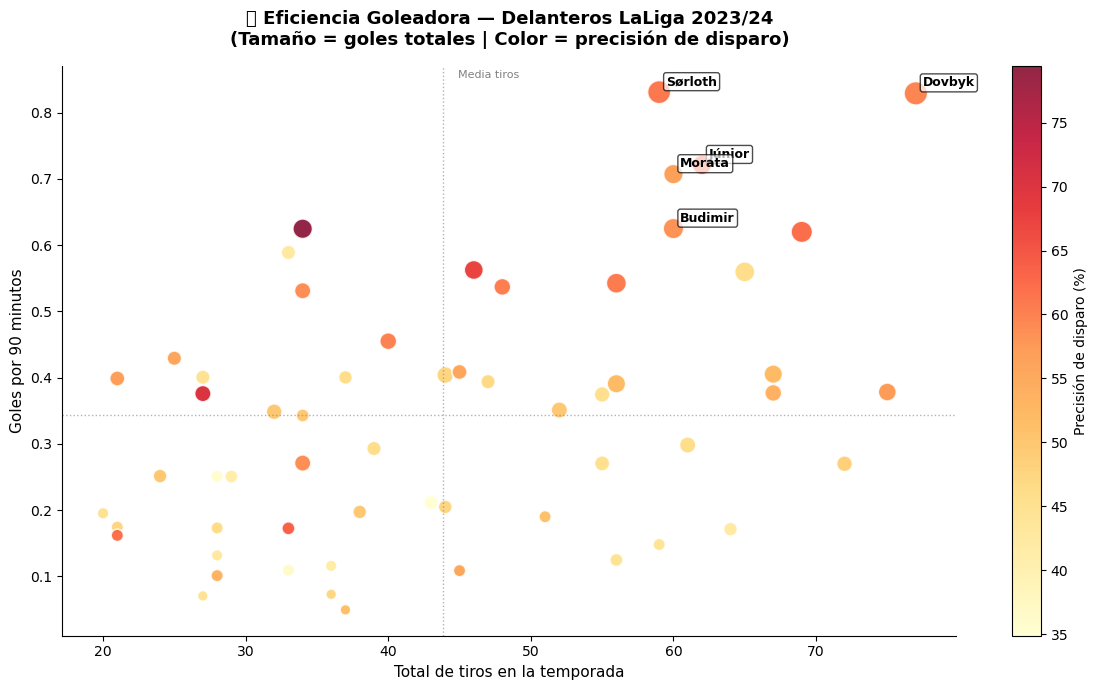

✅ Gráfico 4 guardado

💡 INSIGHT: Cuadrante superior-izquierdo = máxima eficiencia (muchos goles con pocos tiros)
   Cuadrante inferior-derecho = muchos tiros pero baja conversión


In [106]:
# GRÁFICO 4: Goles por 90 min vs Total de tiros (eficiencia individual)
# Solo delanteros y mediapuntas con +900 minutos
df_atac = df_min[
    (df_min['position'].isin(['Striker', 'Attacking Midfielder', 'Forward'])) &
    (df_min['min_jugados'] >= 900) &
    (df_min['total_shots'] >= 20)
].copy()

fig, ax = plt.subplots(figsize=(12, 7))

scatter = ax.scatter(
    df_atac['total_shots'],
    df_atac['goles_p90'],
    s=df_atac['goals'] * 10 + 50,
    c=df_atac['precision_tiro'],
    cmap='YlOrRd', alpha=0.85, edgecolors='white', linewidth=1.2
)

# Anotar jugadores destacados (top 5 en goles p90)
top5 = df_atac.nlargest(5, 'goles_p90')
for _, row in top5.iterrows():
    ax.annotate(
        row['name'].split()[-1],
        (row['total_shots'], row['goles_p90']),
        fontsize=9, fontweight='bold',
        xytext=(5, 5), textcoords='offset points',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7)
    )

plt.colorbar(scatter, ax=ax, label='Precisión de disparo (%)')
ax.set_xlabel('Total de tiros en la temporada', fontsize=11)
ax.set_ylabel('Goles por 90 minutos', fontsize=11)
ax.set_title('🔥 Eficiencia Goleadora — Delanteros LaLiga 2023/24\n(Tamaño = goles totales | Color = precisión de disparo)', 
             fontsize=13, fontweight='bold', pad=15)

# Líneas de referencia (medias)
ax.axvline(df_atac['total_shots'].mean(), color='gray', linestyle=':', alpha=0.6, linewidth=1)
ax.axhline(df_atac['goles_p90'].mean(), color='gray', linestyle=':', alpha=0.6, linewidth=1)
ax.text(df_atac['total_shots'].mean()+1, ax.get_ylim()[1]*0.98, 'Media tiros', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('output/04_eficiencia_goleadora_delanteros.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfico 4 guardado')
print('\n💡 INSIGHT: Cuadrante superior-izquierdo = máxima eficiencia (muchos goles con pocos tiros)')
print('   Cuadrante inferior-derecho = muchos tiros pero baja conversión')

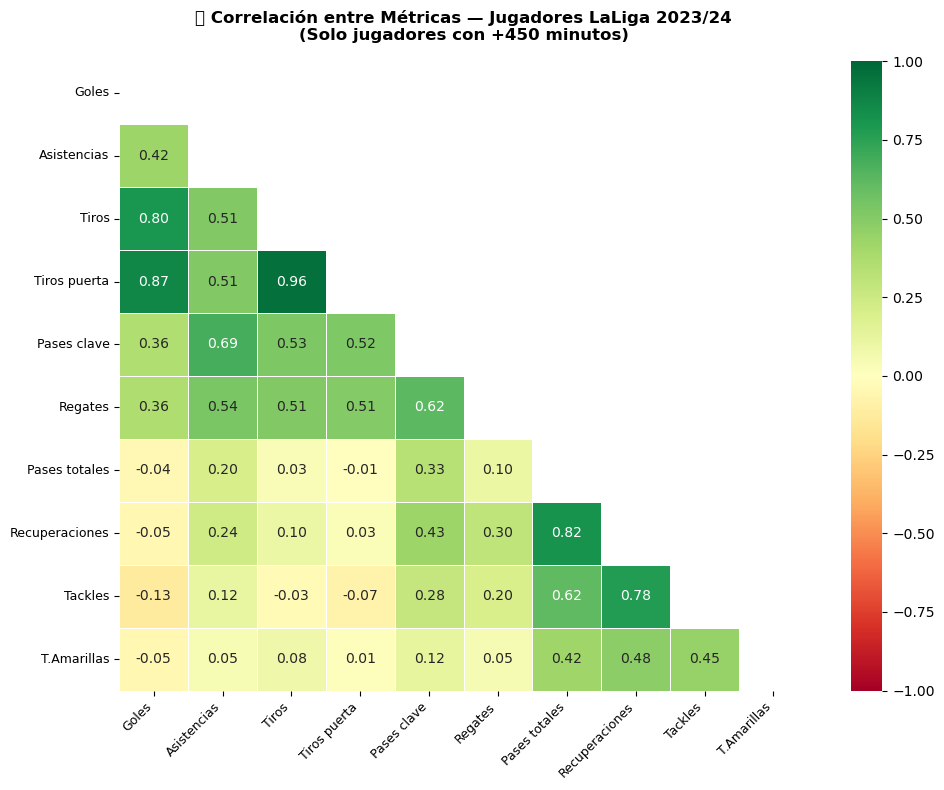

✅ Gráfico 5 guardado


In [108]:
# GRÁFICO 5: Heatmap de correlaciones entre métricas clave
metricas_corr = [
    'goals', 'goal_assists', 'total_shots', 'shots_on_target_inc_goals',
    'key_passes_attempt_assists', 'successful_dribbles',
    'total_passes', 'recoveries', 'tackles_won', 'yellow_cards'
]

corr_matrix = df_min[metricas_corr].corr()

labels = ['Goles', 'Asistencias', 'Tiros', 'Tiros puerta',
          'Pases clave', 'Regates', 'Pases totales',
          'Recuperaciones', 'Tackles', 'T.Amarillas']

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f', 
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax,
    xticklabels=labels, yticklabels=labels
)

ax.set_title('🔗 Correlación entre Métricas — Jugadores LaLiga 2023/24\n(Solo jugadores con +450 minutos)', 
             fontsize=12, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('output/05_heatmap_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfico 5 guardado')

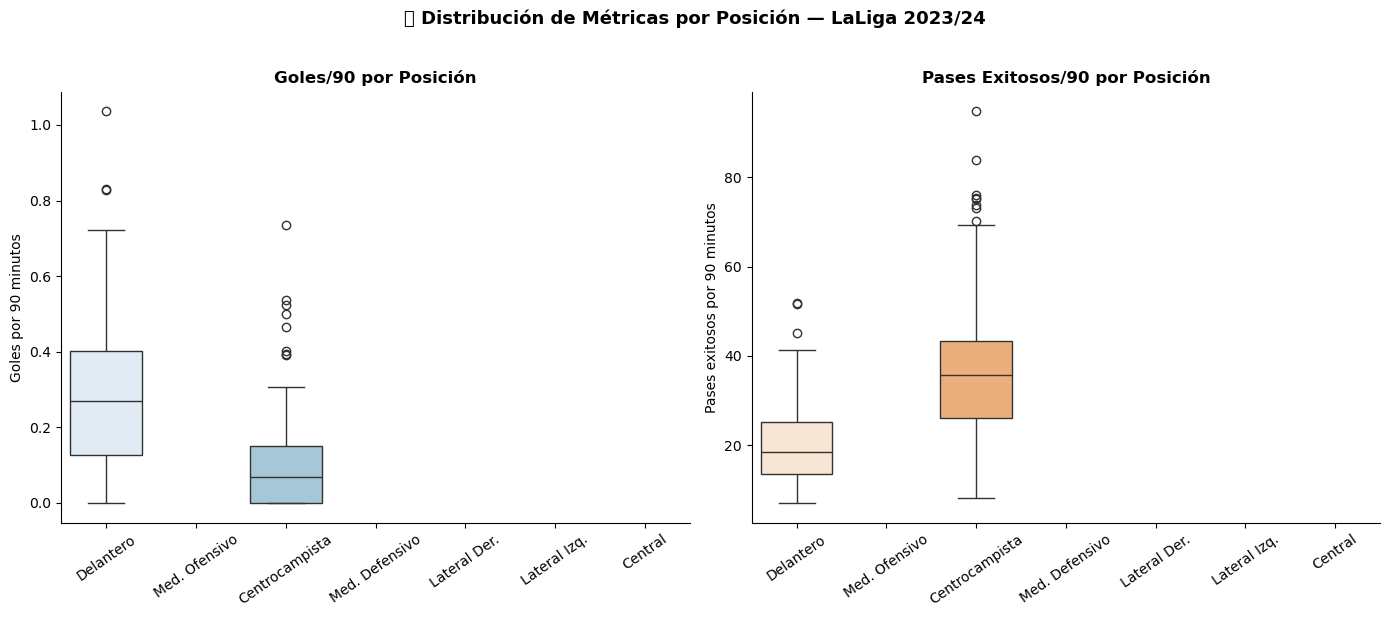

✅ Gráfico 6 guardado


In [110]:
# GRÁFICO 6: Distribución de contribuciones por posición
pos_map = {
    'Striker': 'Delantero', 'Forward': 'Delantero',
    'Attacking Midfielder': 'Med. Ofensivo',
    'Midfielder': 'Centrocampista', 'Defensive Midfielder': 'Med. Defensivo',
    'Right Back': 'Lateral Der.', 'Left Back': 'Lateral Izq.',
    'Centre Back': 'Central'
}
df_min['posicion_esp'] = df_min['position'].map(pos_map).fillna(df_min['position'])

orden = ['Delantero', 'Med. Ofensivo', 'Centrocampista', 'Med. Defensivo', 
         'Lateral Der.', 'Lateral Izq.', 'Central']
df_plot = df_min[df_min['posicion_esp'].isin(orden)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Goles por posición
sns.boxplot(data=df_plot, x='posicion_esp', y='goles_p90', 
            order=orden, palette='Blues', ax=axes[0])
axes[0].set_title('Goles/90 por Posición', fontsize=12, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Goles por 90 minutos')
axes[0].tick_params(axis='x', rotation=35)

# Pases clave por posición
sns.boxplot(data=df_plot, x='posicion_esp', y='pases_exitosos_p90',
            order=orden, palette='Oranges', ax=axes[1])
axes[1].set_title('Pases Exitosos/90 por Posición', fontsize=12, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Pases exitosos por 90 minutos')
axes[1].tick_params(axis='x', rotation=35)

fig.suptitle('📊 Distribución de Métricas por Posición — LaLiga 2023/24', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('output/06_metricas_por_posicion.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfico 6 guardado')

## 5. Insights & Hallazgos Clave

In [112]:
print('=' * 60)
print('📋 RESUMEN DE HALLAZGOS — LaLiga 2023/24')
print('=' * 60)

# Equipo más goleador
top_eq = equipos.nlargest(1, 'goles_totales').iloc[0]
print(f"\n🥇 Equipo más goleador: {top_eq['team']} ({int(top_eq['goles_totales'])} goles)")
print(f"   Goles por partido: {top_eq['goles_por_partido']:.2f}")
print(f"   Precisión de disparo: {top_eq['precision_disparo']:.1f}%")

# Equipo más eficiente
top_ef = equipos[equipos['tiros_totales'] >= 200].nlargest(1, 'precision_disparo').iloc[0]
print(f"\n🎯 Equipo más preciso en el disparo: {top_ef['team']} ({top_ef['precision_disparo']:.1f}%)")

# Máximo goleador
top_j = df_min.nlargest(1, 'goals').iloc[0]
print(f"\n⚽ Máximo goleador: {top_j['name']} ({top_j['team']}) — {int(top_j['goals'])} goles")
print(f"   Goles por 90 min: {top_j['goles_p90']:.2f}")

# Más asistencias
top_a = df_min.nlargest(1, 'goal_assists').iloc[0]
print(f"\n🎩 Más asistencias: {top_a['name']} ({top_a['team']}) — {int(top_a['goal_assists'])} asistencias")

# Jugador más eficiente (goles/tiros) con min 10 goles
df_ef = df_min[(df_min['goals'] >= 8) & (df_min['total_shots'] > 0)].copy()
df_ef['conv_rate'] = df_ef['goals'] / df_ef['total_shots'] * 100
top_conv = df_ef.nlargest(1, 'conv_rate').iloc[0]
print(f"\n💎 Jugador más eficiente (conv. rate): {top_conv['name']} — {top_conv['conv_rate']:.1f}% (min. 8 goles)")

print('\n' + '=' * 60)
print('✅ Análisis S1 completado — Notebook listo para GitHub')
print('=' * 60)

📋 RESUMEN DE HALLAZGOS — LaLiga 2023/24

🥇 Equipo más goleador: Real Madrid (85 goles)
   Goles por partido: 2.66
   Precisión de disparo: 55.6%

🎯 Equipo más preciso en el disparo: Real Madrid (55.6%)

⚽ Máximo goleador: Artem Dovbyk (Girona FC) — 24 goles
   Goles por 90 min: 0.83

🎩 Más asistencias: Álex Baena (Villarreal CF) — 14 asistencias

💎 Jugador más eficiente (conv. rate): Borja Mayoral — 44.1% (min. 8 goles)

✅ Análisis S1 completado — Notebook listo para GitHub


## 6. Próximos Pasos (S2)

En la **Semana 2** trabajaremos SQL avanzado sobre este mismo dataset:
- Window functions: `RANK()`, `LAG()`, `ROLLING AVG` de rendimiento
- Queries de ranking por posición y equipo
- Comparativas de temporada a temporada

---
*Proyecto por: [Tu nombre] | ADE Bilingüe + Data Analytics | Sports Analytics Portfolio*  
*Dataset: La Liga Stats 2023-2024 — Kaggle (Sergio Delgado Quintero)*

In [117]:
cd "C:\Users\jrubi\Desktop\Sports-Analytics Portfolio"
git init
git add .
git commit -m "S1: EDA LaLiga 2023/24 - análisis de equipos y jugadores"
git branch -M main
git remote add origin https://github.com/Jrubiols/S1-EDA-LaLiga-2023-24---an-lisis-de-equipos-y-jugadores
git push -u origin main

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 2-3: truncated \UXXXXXXXX escape (295329370.py, line 1)